In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Sigmoid activation function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Derivative of the sigmoid function
def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

# Parameters for our simple deep network
n_layers = 10 # Number of layers
input_size = 1 # Single input for simplicity
hidden_size = 1 # Single neuron per hidden layer for simplicity

# Initialize weights and biases (small values to start)
weights = []
biases = []

# Initialize weights and biases for each layer
# Using random normal distribution, scaled to prevent immediate saturation
for i in range(n_layers):
    w = np.random.randn(hidden_size, hidden_size) * 0.1 # Weights between layers
    b = np.random.randn(hidden_size, 1) * 0.1 # Bias for each layer
    if i == 0: # First layer input to hidden
        w = np.random.randn(hidden_size, input_size) * 0.1
    weights.append(w)
    biases.append(b)

print(f"Network created with {n_layers} layers.")

Network created with 10 layers.


In [10]:
# Simulate an input
x = np.random.randn(input_size, 1) # Single input value

# --- Forward Pass ---
z_values = [] # Store weighted sums (inputs to activation function)
a_values = [x] # Store activations (outputs of activation function), starting with input

for i in range(n_layers):
    z = np.dot(weights[i], a_values[-1]) + biases[i]
    a = sigmoid(z)
    z_values.append(z)
    a_values.append(a)

# Simulate a simple error for the output layer (e.g., difference from a target)
# This is a placeholder for a loss function derivative, dL/da_L
output_error = np.random.randn(hidden_size, 1) * 0.1

# --- Backward Pass (Backpropagation) ---
gradient_magnitudes = []
dA = output_error # Derivative of Loss w.r.t. output of the last layer

for i in reversed(range(n_layers)):
    dZ = dA * sigmoid_derivative(z_values[i]) # dL/dz_i = dL/da_i * da_i/dz_i

    # The magnitude of the gradient with respect to z_i (before activation)
    # is what often vanishes.
    gradient_magnitudes.append(np.linalg.norm(dZ))

    if i > 0:
        # dL/da_{i-1} = (dL/dz_i) * (dz_i/da_{i-1})
        # dz_i/da_{i-1} is just the weights[i]
        dA = np.dot(weights[i].T, dZ)

# Reverse the list to show gradients from input layer to output layer
gradient_magnitudes.reverse()

print("Gradient magnitudes calculated.")

Gradient magnitudes calculated.


### Visualize the Gradient Magnitudes

Finally, we'll plot the magnitude of the gradients for each layer. You should observe that the gradients become very small for layers closer to the input, demonstrating the vanishing gradient effect.

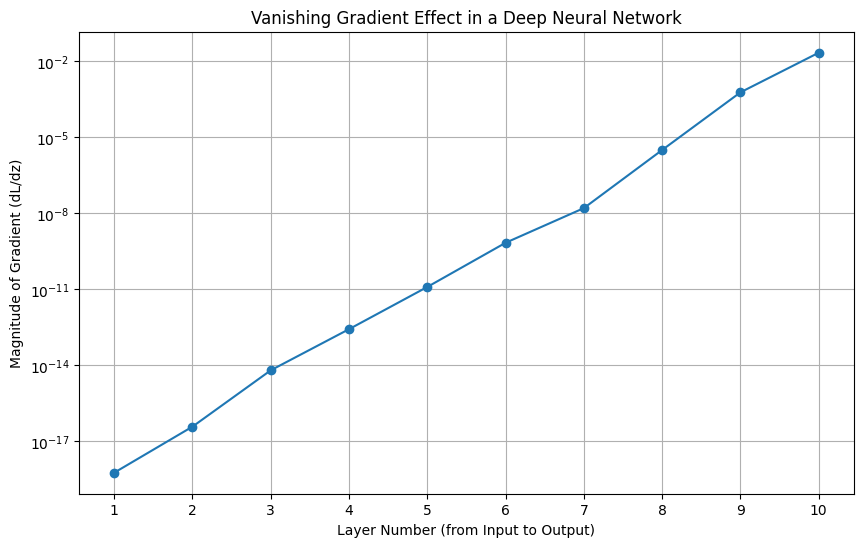

As you can see, the gradient magnitudes decrease significantly for layers closer to the input, demonstrating the vanishing gradient effect. This makes it difficult for the network to learn features in earlier layers.


In [11]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, n_layers + 1), gradient_magnitudes, marker='o')
plt.title('Vanishing Gradient Effect in a Deep Neural Network')
plt.xlabel('Layer Number (from Input to Output)')
plt.ylabel('Magnitude of Gradient (dL/dz)')
plt.yscale('log') # Use log scale to better visualize small values
plt.grid(True)
plt.xticks(range(1, n_layers + 1))
plt.show()

print("As you can see, the gradient magnitudes decrease significantly for layers closer to the input, demonstrating the vanishing gradient effect. This makes it difficult for the network to learn features in earlier layers.")